# 1. Import the Data

In [1]:
cal_housing = read.csv("housing.csv")
fix(cal_housing)

# 2. Explore and Visualize Data for Insights

## a) Number of Entries + Missing Values

In [2]:
print(dim(cal_housing))

[1] 20640    10


In [3]:
print(length(which(is.na(cal_housing$housing_median_age))))

[1] 0


In [4]:
print(length(which(is.na(cal_housing$total_rooms))))

[1] 0


In [5]:
print(length(which(is.na(cal_housing$total_bedrooms))))

[1] 207


In [6]:
for (i in 1:ncol(cal_housing)) {
    cat(names(cal_housing)[i], ": ")
    cat(length(which(is.na(cal_housing[,i]))), "\n")
}

longitude : 0 
latitude : 0 
housing_median_age : 0 
total_rooms : 0 
total_bedrooms : 207 
population : 0 
households : 0 
median_income : 0 
median_house_value : 0 
ocean_proximity : 0 


There are 20,640 entries in the dataset! There are no NA values in housing_median_age or total_rooms, but there are 207 in total_bedrooms. No other column has missing values.

## b) Levels

In [2]:
cal_housing$ocean_proximity = factor(cal_housing$ocean_proximity)
print(levels(cal_housing$ocean_proximity))

[1] "<1H OCEAN"  "INLAND"     "ISLAND"     "NEAR BAY"   "NEAR OCEAN"


This factor has 5 levels listed above. 

## c) Histograms

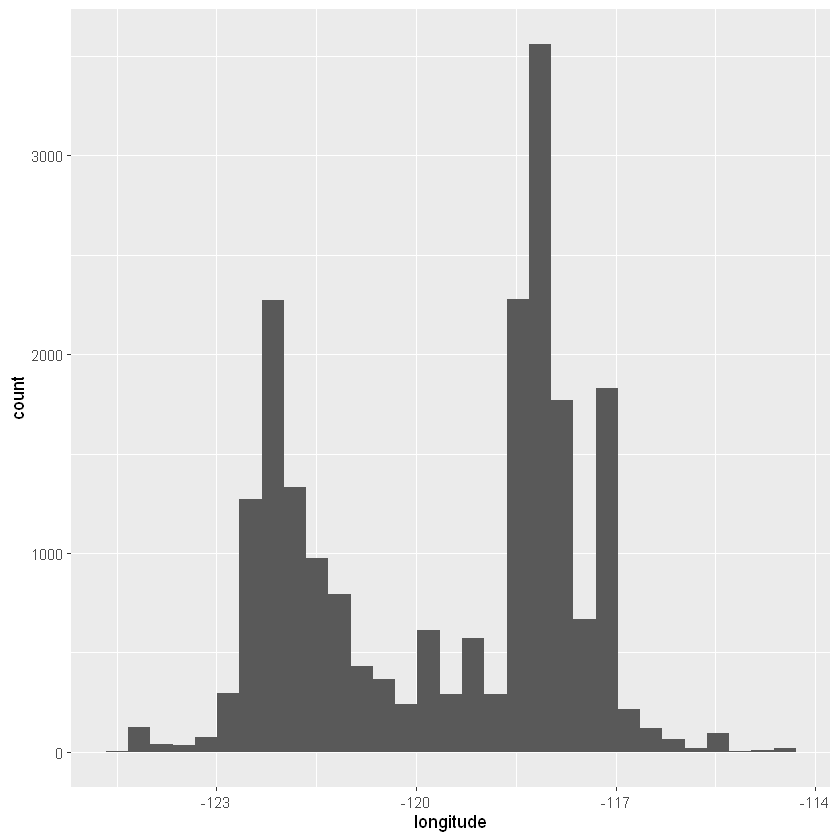

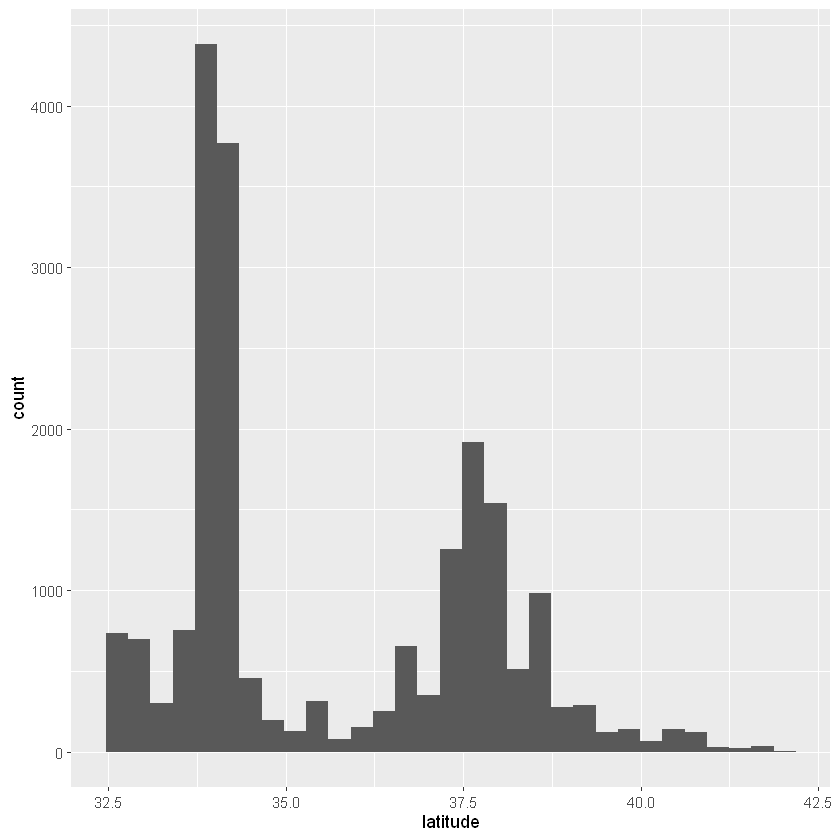

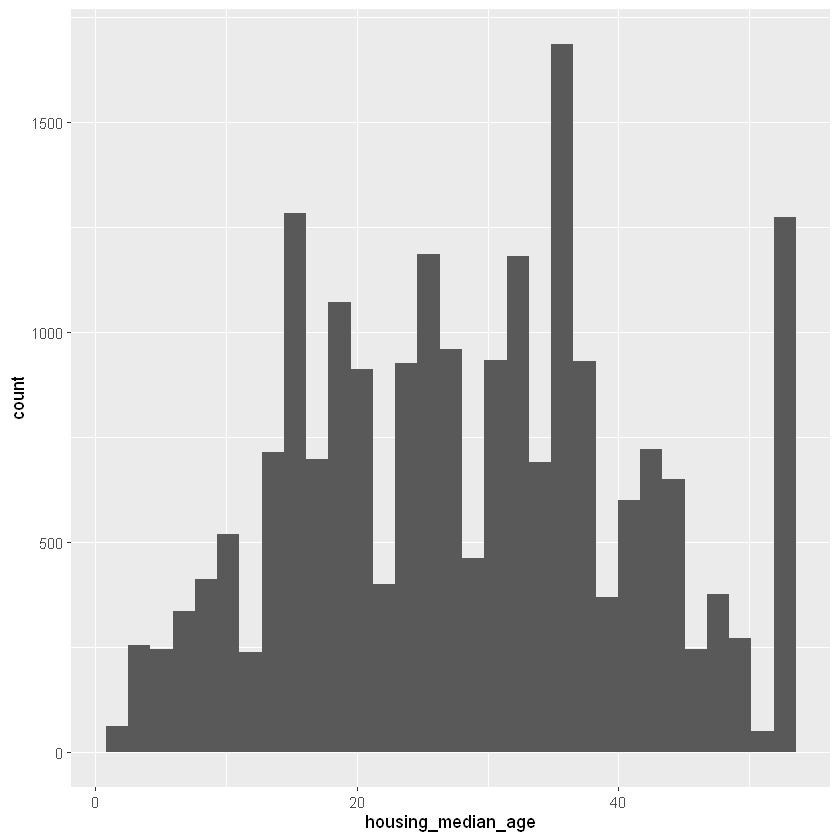

Warning message:
"Removed 207 rows containing non-finite outside the scale range (`stat_bin()`)."


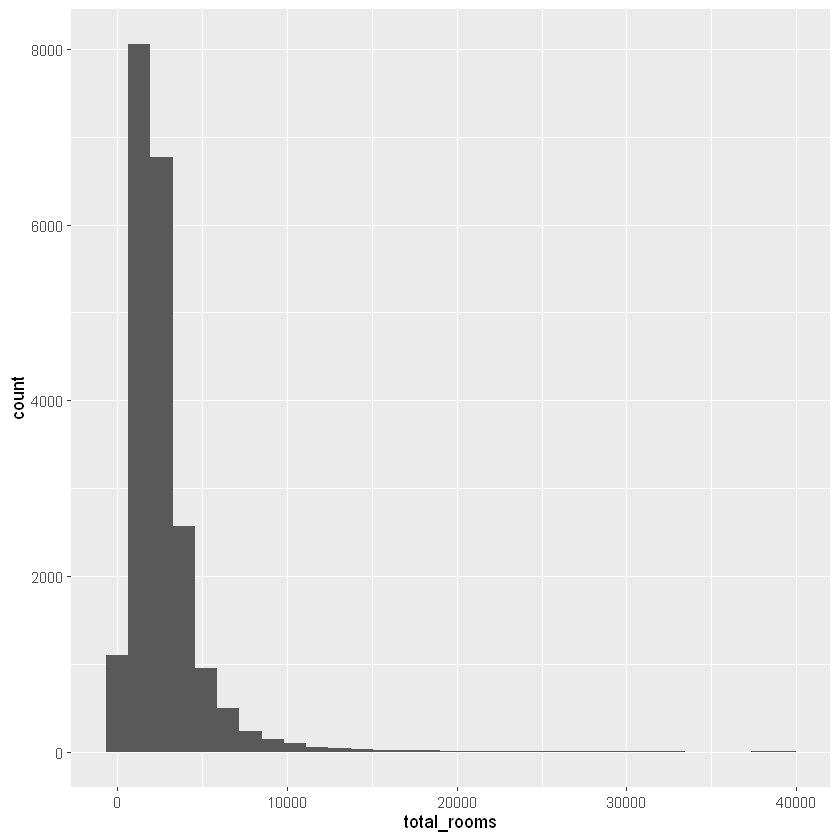

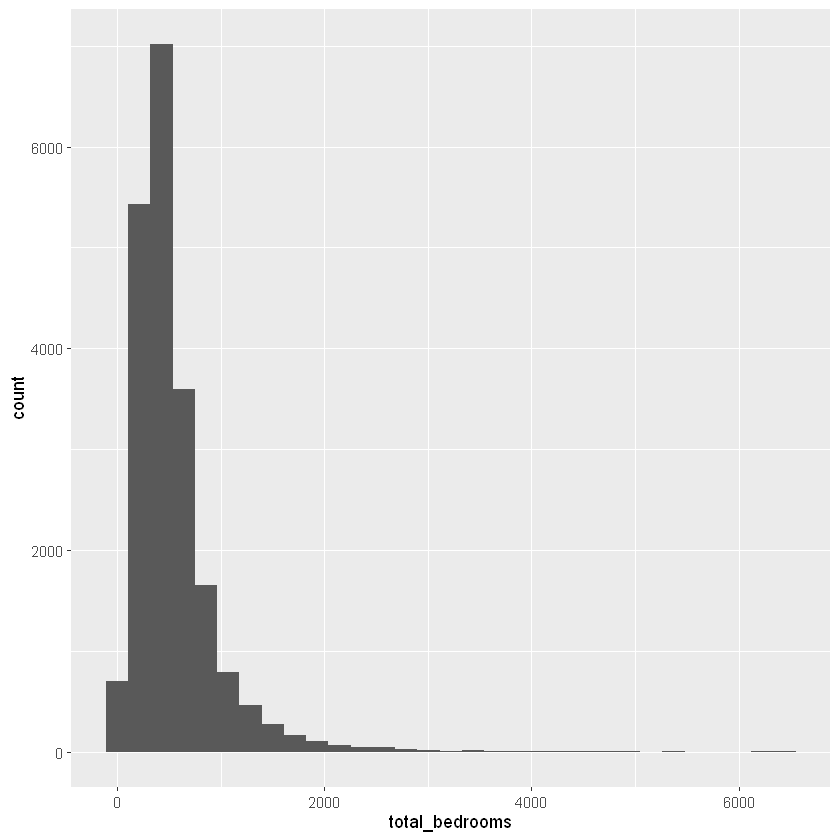

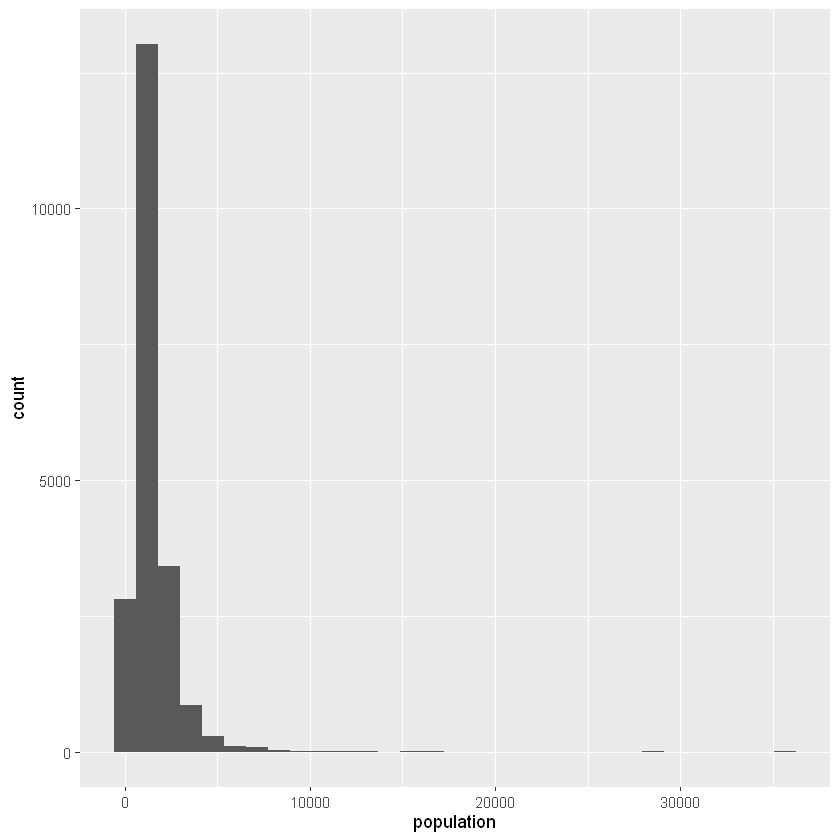

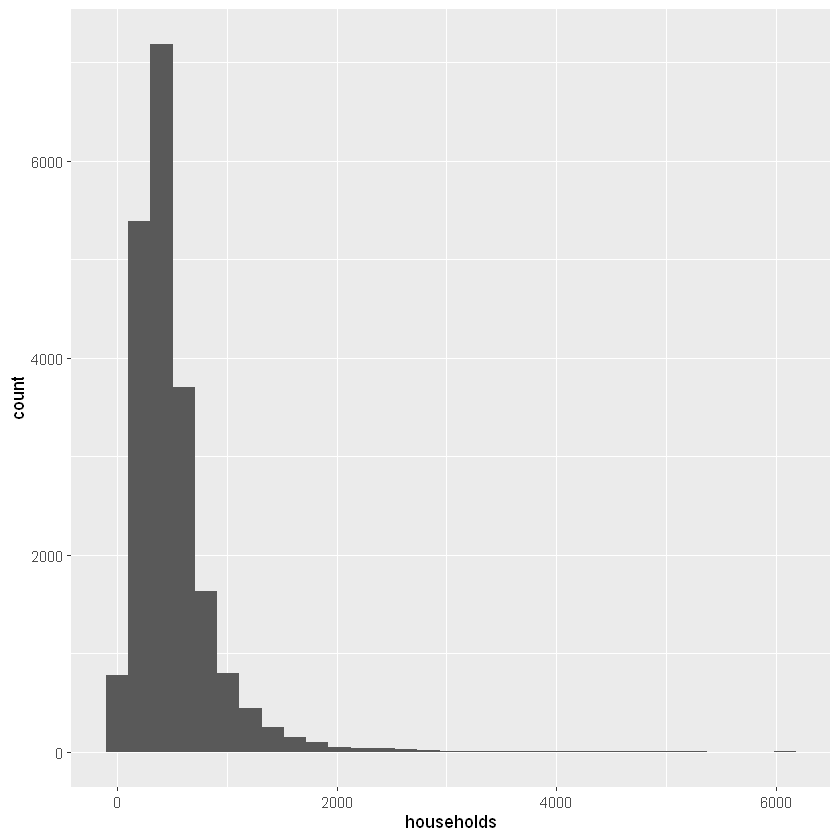

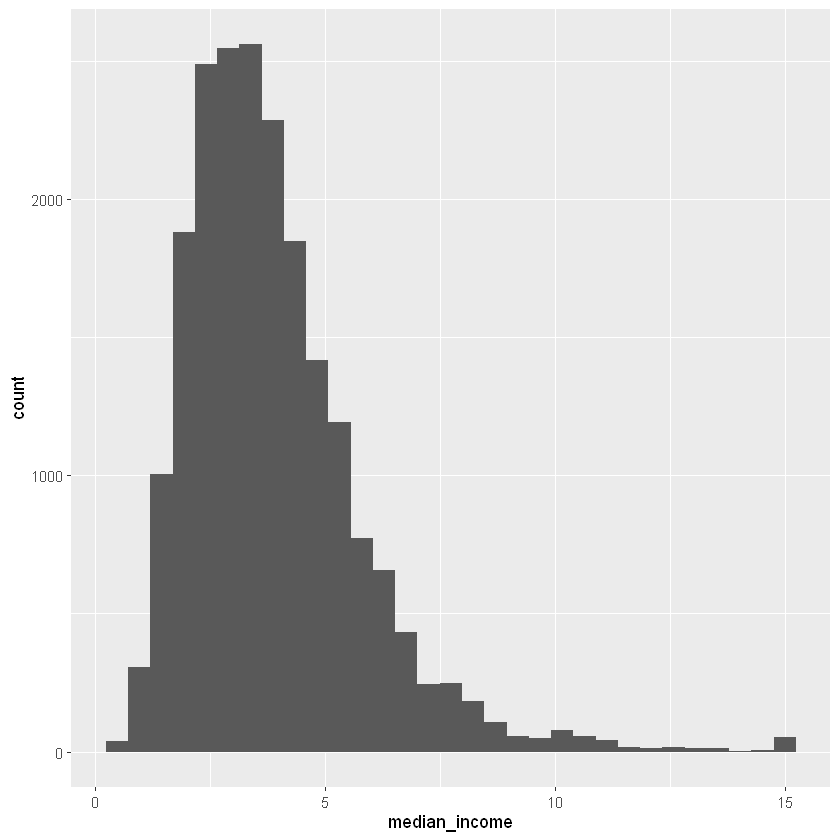

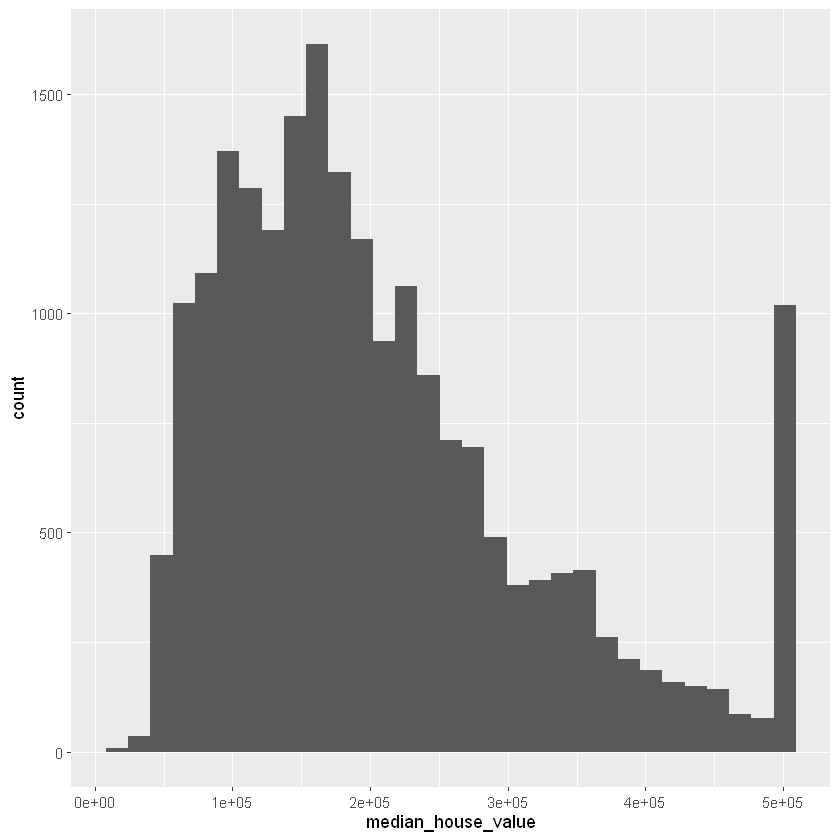

In [8]:
library(ggplot2)
for (i in 1:(ncol(cal_housing)-1)) {
    print(ggplot(cal_housing, aes(x=cal_housing[,i])) +
          geom_histogram(binwidth=(max(cal_housing[,i], na.rm = TRUE)-min(cal_housing[,i], na.rm = TRUE))/30) +
          labs(x=names(cal_housing)[i]))
}

We probably don't expect any sort of distribution for latitude and longitude, as there will be peaks corresponding to big neighborhoods and valleys corresponding to regions where there aren't many houses. All the other variables, we might expect a somewhat normal/skewed distribution with a tail, which we see in most of them.

Three variables do appear to be capped however, with large unexpected peaks on the highest bin: housing_median_age, median_income, and median_house_value with a max of 52, 15, and 500,000 respectively.

List of variables:
* longitude: Degrees east of Prime Meridian (since values of negative, it points west)
* latitude: Degrees north of equator (combined with longitude, these values point to California as we would expect by the title of the dataset)
* housing_median_age: Median age of house in years
* total_rooms: Total number of rooms in area
* total_bedrooms: Total number of bedrooms in the area
* population: Number of people living in area
* households: Number of households in area
* median_income: Most likely in units of $10,000 and represents the median income of the area
* median_house_value: Units of dollars and represents the median house value of the area
* ocean_proximity: Factor varaible indicating how close the area is to the ocean

## d) Scatter Plot

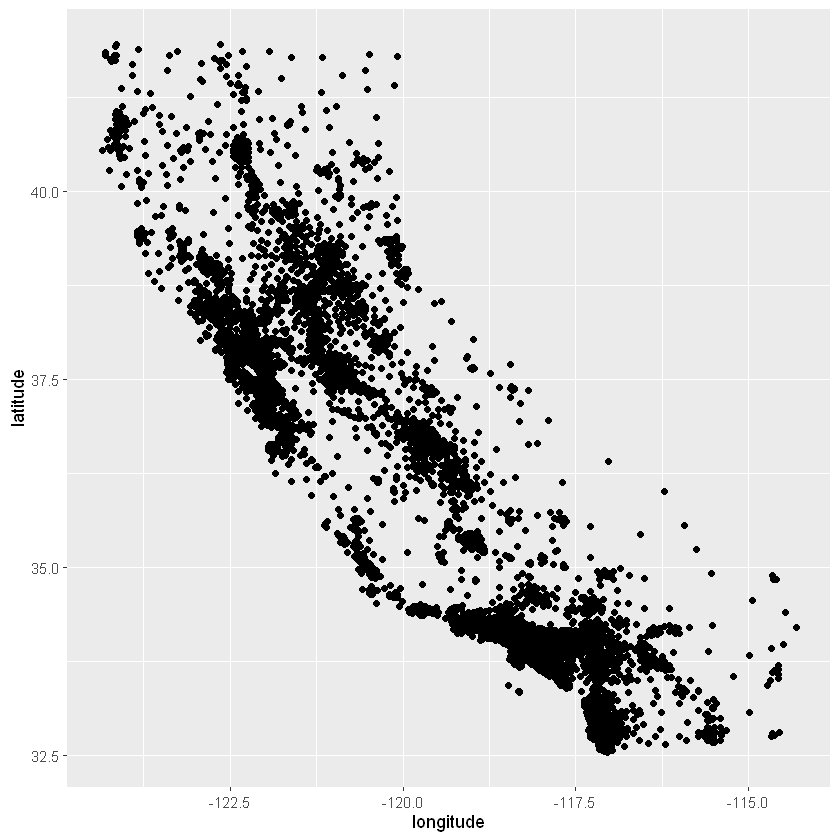

In [9]:
ggplot(cal_housing, aes(x=longitude, y=latitude)) + geom_point()

As we can see it roughly traces out the outline of California! We can see that the data isn't evenly spaced though - some areas have a lot more data points than others.

## e) Correlation Coefficient

In [10]:
for (i in 1:(ncol(cal_housing)-2)) {
    cat(names(cal_housing)[i], ": ")
    cat(cor(cal_housing[,i], cal_housing$median_house_value), "\n")
}

longitude : -0.04596662 
latitude : -0.1441603 
housing_median_age : 0.1056234 
total_rooms : 0.1341531 
total_bedrooms : NA 
population : -0.02464968 
households : 0.06584265 
median_income : 0.6880752 


The correlation coefficient tells us how likely there is to be a linear relationship between the two variables. As we can see most values are pretty low, but medain_income has a coefficient of 0.688 meaning that as income increases, housing prices also tend to increase (which makes sense intuitively).

# 3. Prepare The Data for Machine Learning Algorithms

## a) Dealing with Missing Data

In [3]:
cal_housing$total_bedrooms[is.na(cal_housing$total_bedrooms)] = median(cal_housing$total_bedrooms, na.rm=TRUE)

In [12]:
summary(cal_housing$total_bedrooms)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0   297.0   435.0   536.8   643.2  6445.0 

## b) Data Cleaning

In [5]:
library(dplyr)

In [6]:
cal_housing = cal_housing %>%
    filter(median_house_value < 500000) %>%
    mutate(rooms_per_house = total_rooms / households) %>%
    mutate(population_per_house = population / households) %>%
    mutate(ocean_proximity = as.factor(ocean_proximity)) %>%
    mutate_at(vars(-ocean_proximity, -median_house_value, - median_income), funs(scale)) %>%
    data.matrix %>% data.frame

Warning message:
"`funs()` was deprecated in dplyr 0.8.0.
ℹ Please use a list of either functions or lambdas:

# Simple named list: list(mean = mean, median = median)

# Auto named with `tibble::lst()`: tibble::lst(mean, median)

# Using lambdas list(~ mean(., trim = .2), ~ median(., na.rm = TRUE))"


In [7]:
set.seed(365)
train_id = sample(nrow(cal_housing), size = 0.8*nrow(cal_housing))
train_set = cal_housing[train_id,]
test_set = cal_housing[-train_id,]
print(paste(nrow(train_set), "train +", nrow(test_set), "test"))

[1] "15718 train + 3930 test"


In [8]:
cal_housing = cal_housing %>%
    mutate(income_level = ceiling(median_income/2)) %>%
    mutate(income_level = factor(ifelse(income_level >= 5, 5, income_level))) %>%
    select(-median_income)

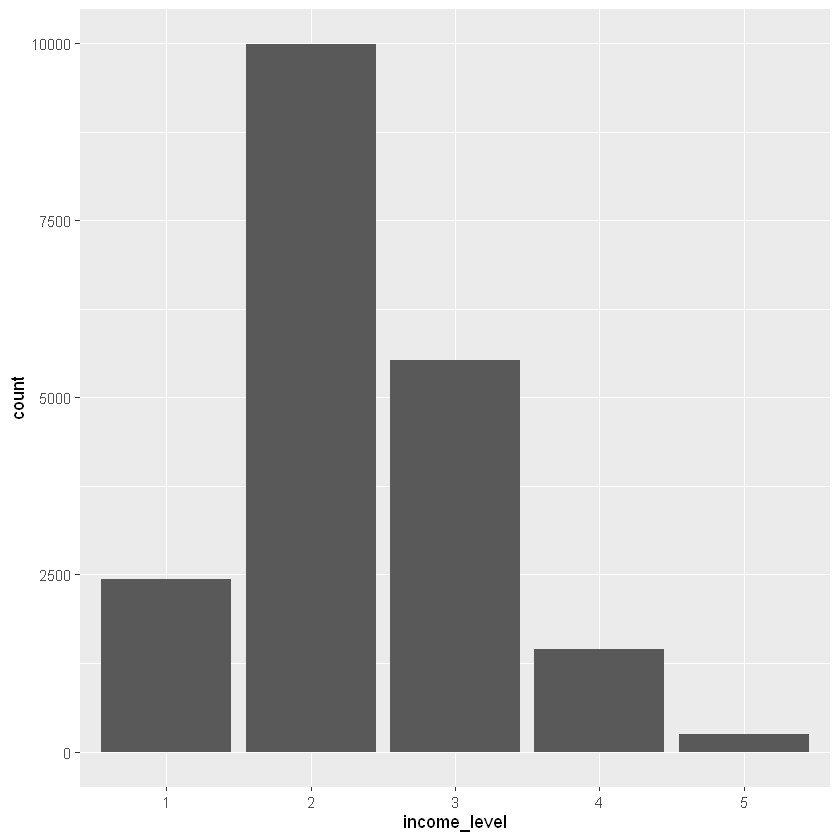

In [18]:
ggplot(cal_housing, aes(x=income_level)) + geom_bar()

In [10]:
library(caret)

In [11]:
train_str_id = createDataPartition(cal_housing$income_level, p =.8, list = FALSE, times = 1)
train_str = cal_housing[train_str_id,]
test_str = cal_housing[-train_str_id,]

# 4. Fit models on the dataset

## a) Linear Regression

In [22]:
model_lm = lm(median_house_value~., data=train_str)
predict_lm_train = predict(model_lm, train_str)

In [23]:
sqrt(mean((train_str$median_house_value - predict_lm_train)^2))

[1] 63519.21

## b) Decision Tree and SVM

In [24]:
library(rpart)
model_decision_tree = rpart(median_house_value~.,data = train_str, method = "anova", control = rpart.control(minsplit = 2,cp=0.001))

predict_decision_tree = predict(model_decision_tree, train_str)

sqrt(mean((train_str$median_house_value -predict_decision_tree)^2))

[1] 53688.64

In [13]:
library(e1071)

In [27]:
model_svm = svm(median_house_value~.,data = train_str, cost = 10)
predict_svm = predict(model_svm, train_str)
sqrt(mean((train_str$median_house_value - predict_svm)^2))

[1] 50385.78

# c) $k$-Fold Cross-Validation

In [28]:
cal_housing_copy = cal_housing[sample(nrow(cal_housing)),]

folds = cut(seq(1,nrow(cal_housing_copy)),breaks=10,labels=FALSE)

In [29]:
MSE_lm = 0
MSE_tree = 0
MSE_svm = 0
for(i in 1:10){
    start = Sys.time()
    print(i)
    flush.console()
    testIndexes = which(folds==i,arr.ind=TRUE)
    testData = cal_housing_copy[testIndexes, ]
    trainData = cal_housing_copy[-testIndexes, ]

    lm_model = lm(median_house_value~., trainData)
    tree_model = rpart(median_house_value~.,data = trainData, method = "anova", control = rpart.control(minsplit = 2, cp = 0.001))
    print("start")
    flush.console()
    svm_model = svm(median_house_value~.,data = trainData, cost = 10)
    print("end")
    flush.console()
    predict1 = predict(lm_model, testData)
    predict2 = predict (tree_model, testData)
    predict3 = predict(svm_model, testData)

    MSE_lm = MSE_lm + sum(folds == i)/nrow(cal_housing_copy) * mean((predict1 - testData$median_house_value)^2)
    MSE_tree = MSE_tree + sum(folds == i)/nrow(cal_housing_copy) * mean((predict2 - testData$median_house_value)^2)
    MSE_svm = MSE_svm + sum(folds == i)/nrow(cal_housing_copy) * mean((predict3 - testData$median_house_value)^2)
    end = Sys.time()
    print(end - start)
    flush.console()
}

[1] 1
[1] "start"
[1] "end"
Time difference of 1.649274 mins
[1] 2
[1] "start"
[1] "end"
Time difference of 1.644449 mins
[1] 3
[1] "start"
[1] "end"
Time difference of 1.650031 mins
[1] 4
[1] "start"
[1] "end"
Time difference of 1.670681 mins
[1] 5
[1] "start"
[1] "end"
Time difference of 1.632649 mins
[1] 6
[1] "start"
[1] "end"
Time difference of 1.653582 mins
[1] 7
[1] "start"
[1] "end"
Time difference of 1.666391 mins
[1] 8
[1] "start"
[1] "end"
Time difference of 1.722028 mins
[1] 9
[1] "start"
[1] "end"
Time difference of 1.634142 mins
[1] 10
[1] "start"
[1] "end"
Time difference of 1.550696 mins


In [30]:
sqrt(MSE_lm)
sqrt(MSE_tree)
sqrt(MSE_svm)

[1] 63763.77

[1] 55256.87

[1] 52587.59

# 5. Fine Tuning

## a) Decision Tree

In [15]:
tuneResult1 = tune.rpart(median_house_value~., data = train_str, minsplit = c(5,10,15, 20), cp = c(0.1,0.01,0.001,0.0001))
tune_tree = tuneResult1$best.model

In [16]:
predict_tree = predict(tune_tree, train_str)
sqrt(mean((train_str$median_house_value - predict_tree)^2))

[1] 39894.09

## b) SVM

In [17]:
tuneResult2 = tune.svm(median_house_value ~., data = train_str, cost=10^(-1:2), gamma=c(0.1,0,1))
tune_svm = tuneResult2$best.model

In [18]:
predict_svm = predict(tune_svm, train_str)
sqrt(mean((train_str$median_house_value - predict_svm)^2))

[1] 44243.84

## c) Evaluate on Test Set

In [19]:
predict_tree_final = predict(tune_tree, test_str)
sqrt(mean((test_str$median_house_value - predict_tree_final)^2))

[1] 54334.88

In [20]:
predict_svm_final = predict(tune_svm, test_str)
sqrt(mean((test_str$median_house_value - predict_svm_final)^2))

[1] 50677.15